# Gerando o gráfico que juntas os 5

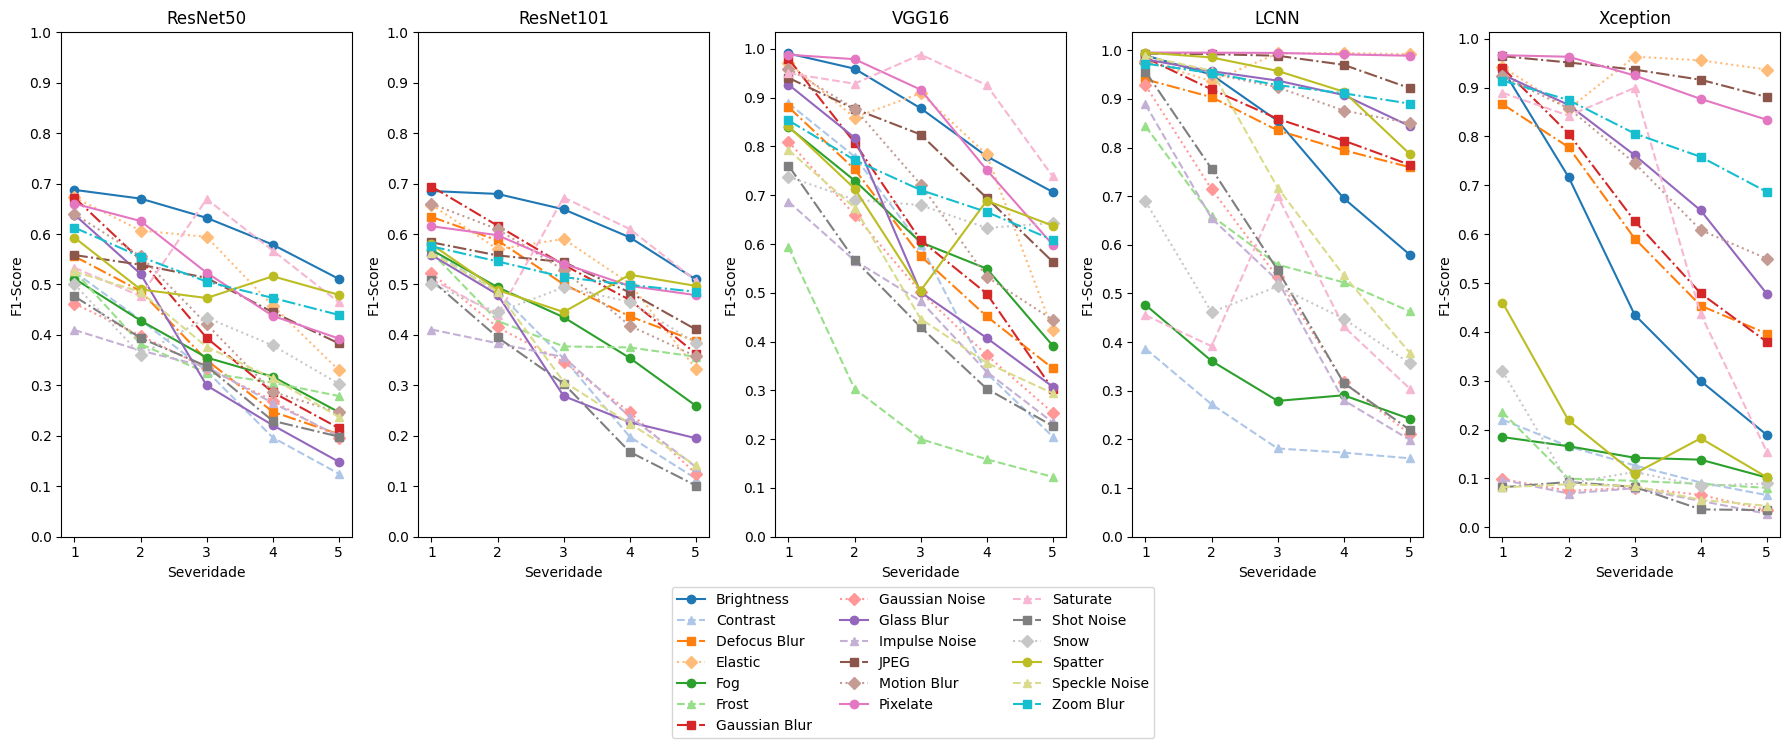

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Caminhos dos arquivos .xlsx
caminhos_arquivos = [
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_ResNet50.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_ResNet101.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_VGG16.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_LCNN.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_Xception.xlsx"
]

# Nome das colunas que você deseja extrair
colunas_desejadas = ['f1-score', 'corruption']

# Criar uma figura com 3 subplots lado a lado
fig, axs = plt.subplots(1, 5, figsize=(18, 6))  # 1 linha, 3 colunas, tamanho total da figura 18x6

# Títulos personalizados para cada gráfico
titulos = ['ResNet50', 'ResNet101', 'VGG16', 'LCNN', 'Xception']

# Função para processar e plotar os dados
def processar_e_plotar(df, ax, titulo):
    novodf = pd.DataFrame(columns=['corruption', 'severidade', 'f1-score'])

    # Iterar sobre as linhas do DataFrame
    for index, row in df.iterrows():
        # String de exemplo
        string = row['corruption']
        # Dividir a string em uma lista de palavras
        parts = string.split()
        corrupcao = ''
        severidade = 0
        # Verificar se a lista tem exatamente 3 elementos
        if len(parts) == 3:
            corrupcao = parts[0]
            severidade = int(parts[2])  # Convertendo para inteiro
        elif len(parts) == 4:
            corrupcao = parts[0] + " " + parts[1]
            severidade = int(parts[3])  # Convertendo para inteiro
        
        novodf.loc[index] = [corrupcao, severidade, row['f1-score']]

    # Lista de cores únicas para as linhas (usando uma paleta maior)
    cores = plt.cm.tab20.colors  # Usa 20 cores únicas

    # Lista de estilos de linhas e marcadores
    linestyles = ['-', '--', '-.', ':']  # Estilos de linhas
    markers = ['o', '^', 's', 'D']       # Marcadores (bolinha, triângulo, quadrado, diamante)

    # Dicionário para mapear cada corrupção a uma cor única
    cor_mapping = {}
    cor_index = 0

    # Agrupar os dados por corrupção
    for i, (name, group) in enumerate(novodf.groupby('corruption')):
        # Ordenar os valores de severidade
        group = group.sort_values(by='severidade')
        
        # Atribuir uma cor única para cada corrupção
        if name not in cor_mapping:
            cor_mapping[name] = cores[cor_index]
            cor_index = (cor_index + 1) % len(cores)  # Avança para a próxima cor
        
        # Escolher o estilo de linha e marcador alternadamente
        linestyle = linestyles[i % len(linestyles)]
        marker = markers[i % len(markers)]
        
        # Plotar o gráfico com a cor única e estilo alternado
        ax.plot(group['severidade'], group['f1-score'], marker=marker, linestyle=linestyle, label=name, color=cor_mapping[name])

    # Adicionar rótulos e título
    ax.set_xlabel('Severidade')
    ax.set_ylabel('F1-Score')
    ax.set_title(titulo)  # Usar o título personalizado

    # Definir os ticks do eixo x como 1, 2, 3, 4, 5
    ax.set_xticks([1, 2, 3, 4, 5])

    # Adicionar mais ticks no eixo y
    ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

# Loop para processar e plotar cada arquivo
for i, (caminho_arquivo, titulo) in enumerate(zip(caminhos_arquivos, titulos)):
    # Ler o arquivo Excel e selecionar as colunas desejadas
    df = pd.read_excel(caminho_arquivo, usecols=colunas_desejadas)
    
    # Processar e plotar no subplot correspondente
    processar_e_plotar(df, axs[i], titulo)  # Passar o título personalizado

# Criar uma única legenda para todos os gráficos
handles, labels = axs[0].get_legend_handles_labels()  # Coletar handles e labels do primeiro gráfico
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.51, -0.25), ncol=3)  # Legenda única mais embaixo

# Ajustar o layout para evitar sobreposição
plt.tight_layout()

# Salvar o gráfico como uma imagem
caminho_salvar_imagem = r"../resultadosDasRedes/grafico_da_avaliacao-corrupcoes_com_as_5-redes.png"
plt.savefig(caminho_salvar_imagem, bbox_inches='tight', dpi=300)  # Salvar em alta resolução (300 dpi)

# Mostrar o gráfico
plt.show()

# Criando tabela do top3 e bottom3

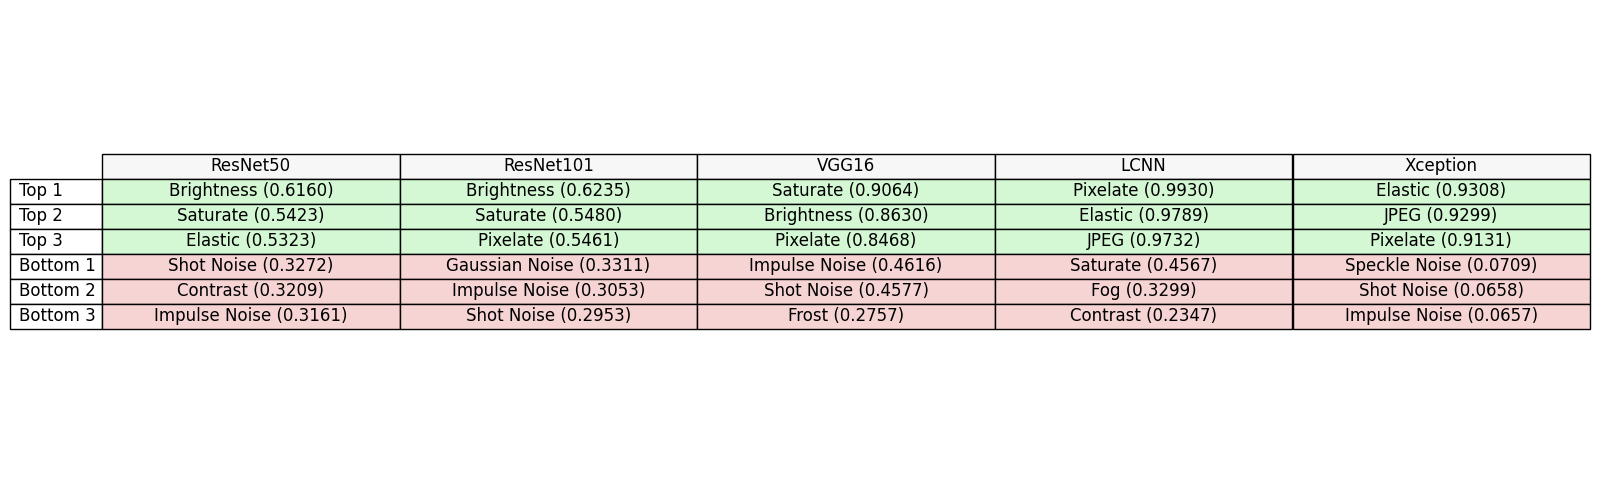

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.table import Table

# Caminhos dos arquivos .xlsx


caminhos_arquivos = [
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_ResNet50.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_ResNet101.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_VGG16.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_LCNN.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_Xception.xlsx"
]


# Nome das colunas que você deseja extrair
colunas_desejadas = ['f1-score', 'corruption']

# Nomes dos modelos
# nomes_modelos = ['ResNet50', 'ResNet101', 'VGG16']
nomes_modelos = ['ResNet50', 'ResNet101', 'VGG16', 'LCNN', 'Xception']

# Função para processar os dados e calcular as médias
def processar_e_calcular_medias(df):
    novodf = pd.DataFrame(columns=['corruption', 'severidade', 'f1-score'])

    # Iterar sobre as linhas do DataFrame
    for index, row in df.iterrows():
        # String de exemplo
        string = row['corruption']
        # Dividir a string em uma lista de palavras
        parts = string.split()
        corrupcao = ''
        severidade = 0
        # Verificar se a lista tem exatamente 3 elementos
        if len(parts) == 3:
            corrupcao = parts[0]
            severidade = int(parts[2])  # Convertendo para inteiro
        elif len(parts) == 4:
            corrupcao = parts[0] + " " + parts[1]
            severidade = int(parts[3])  # Convertendo para inteiro
        
        novodf.loc[index] = [corrupcao, severidade, row['f1-score']]

    # Calcular a média do f1-score para cada corrupção
    medias = novodf.groupby('corruption')['f1-score'].mean().reset_index()
    medias = medias.sort_values(by='f1-score', ascending=False)

    return medias

# Lista para armazenar os resultados de cada modelo
resultados = []

# Loop para processar cada arquivo
for caminho_arquivo, nome_modelo in zip(caminhos_arquivos, nomes_modelos):
    # Ler o arquivo Excel e selecionar as colunas desejadas
    df = pd.read_excel(caminho_arquivo, usecols=colunas_desejadas)
    
    # Processar e calcular as médias
    medias = processar_e_calcular_medias(df)
    
    # Adicionar o nome do modelo ao DataFrame
    medias['Modelo'] = nome_modelo
    
    # Adicionar os resultados à lista
    resultados.append(medias)

# Concatenar todos os resultados em um único DataFrame
resultados_concatenados = pd.concat(resultados, ignore_index=True)

# Função para obter o top 3 e o bottom 3 de cada modelo
def obter_top_bottom_3(df):
    top3 = df.head(3).copy()  # Usar .copy() para evitar SettingWithCopyWarning
    bottom3 = df.tail(3).copy()  # Usar .copy() para evitar SettingWithCopyWarning
    
    # Adicionar coluna de posição
    top3['Posição'] = ['Top 1', 'Top 2', 'Top 3']
    bottom3['Posição'] = ['Bottom 1', 'Bottom 2', 'Bottom 3']
    
    return top3, bottom3

# Criar uma tabela final com o top 3 e o bottom 3 de cada modelo
tabela_final = pd.DataFrame()

for nome_modelo in nomes_modelos:
    df_modelo = resultados_concatenados[resultados_concatenados['Modelo'] == nome_modelo].copy()  # Usar .copy() para evitar SettingWithCopyWarning
    top3, bottom3 = obter_top_bottom_3(df_modelo)
    
    # Concatenar top 3 e bottom 3
    tabela_final = pd.concat([tabela_final, top3, bottom3], ignore_index=True)

# Reorganizar a tabela para o formato desejado
tabela_reorganizada = pd.DataFrame()

# Definir as linhas de ranqueamento
linhas_ranqueamento = ['Top 1', 'Top 2', 'Top 3', 'Bottom 1', 'Bottom 2', 'Bottom 3']

# Preencher a tabela reorganizada
for posicao in linhas_ranqueamento:
    dados_posicao = []
    for nome_modelo in nomes_modelos:
        # Filtrar os dados para a posição e modelo atual
        filtro = tabela_final[(tabela_final['Modelo'] == nome_modelo) & (tabela_final['Posição'] == posicao)]
        if not filtro.empty:
            dados_posicao.append(f"{filtro['corruption'].values[0]} ({filtro['f1-score'].values[0]:.4f})")
        else:
            dados_posicao.append("")  # Caso não haja dados
    tabela_reorganizada[posicao] = dados_posicao

# Definir os modelos como índice da tabela
tabela_reorganizada.index = nomes_modelos

# Transpor a tabela para que as redes sejam colunas e as posições sejam linhas
tabela_reorganizada = tabela_reorganizada.T

# Salvar a tabela em um arquivo Excel (opcional)
caminho_salvar_tabela_excel = r"../resultadosDasRedes/tabela_reorganizada_top3-e-bottom3.xlsx"
tabela_reorganizada.to_excel(caminho_salvar_tabela_excel)

# Criar uma figura para a tabela
# fig, ax = plt.subplots(figsize=(12, 6))  # Tamanho da figura
fig, ax = plt.subplots(figsize=(16, 6))  # Aumentei a largura de 12 para 16
ax.axis('off')  # Desativar eixos

# Criar a tabela usando matplotlib
tabela = ax.table(
    cellText=tabela_reorganizada.values,  # Dados da tabela
    rowLabels=tabela_reorganizada.index,  # Rótulos das linhas
    colLabels=tabela_reorganizada.columns,  # Rótulos das colunas
    cellLoc='center',  # Alinhamento do texto nas células
    loc='center',  # Posição da tabela na figura
    colColours=['#f7f7f7'] * len(tabela_reorganizada.columns)  # Cor de fundo do cabeçalho
)

# Ajustar o estilo da tabela
tabela.auto_set_font_size(False)  # Desativar ajuste automático do tamanho da fonte
tabela.set_fontsize(12)  # Definir tamanho da fonte
tabela.scale(1.2, 1.5)  # Escalar a tabela

# Adicionar cores para destacar o Top 3 e Bottom 3
for i in range(len(tabela_reorganizada)):
    if i < 3:  # Top 3
        for j in range(len(tabela_reorganizada.columns)):
            tabela[(i + 1, j)].set_facecolor('#d4f7d4')  # Verde claro
    else:  # Bottom 3
        for j in range(len(tabela_reorganizada.columns)):
            tabela[(i + 1, j)].set_facecolor('#f7d4d4')  # Vermelho claro

# Salvar a tabela como uma imagem PNG
caminho_salvar_imagem = r"../resultadosDasRedes/tabela_TOP3eBOTTOM3.png"
plt.savefig(caminho_salvar_imagem, bbox_inches='tight', dpi=300)  # Salvar em alta resolução (300 dpi)

# Mostrar a tabela (opcional)
plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.table import Table

# Caminhos dos arquivos .xlsx (adicione todos os modelos que você tem)
caminhos_arquivos = [
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_ResNet50.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_ResNet101.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_VGG16.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_LCNN.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_Xception.xlsx"
]


# Nome dos modelos (deve corresponder à ordem dos caminhos_arquivos)
nomes_modelos = ['ResNet50', 'ResNet101', 'VGG16', 'LCNN', 'Xception']  # Adicione outros modelos aqui

# Nome das colunas que você deseja extrair
colunas_desejadas = ['f1-score', 'corruption']

# Função para processar os dados (igual à sua função original)
def processar_e_calcular_medias(df):
    novodf = pd.DataFrame(columns=['corruption', 'severidade', 'f1-score'])

    for index, row in df.iterrows():
        string = row['corruption']
        parts = string.split()
        corrupcao = ''
        severidade = 0
        
        if len(parts) == 3:
            corrupcao = parts[0]
            severidade = int(parts[2])
        elif len(parts) == 4:
            corrupcao = parts[0] + " " + parts[1]
            severidade = int(parts[3])
        
        novodf.loc[index] = [corrupcao, severidade, row['f1-score']]

    return novodf

# Processar todos os arquivos e combinar os dados
dados_combinados = pd.DataFrame()

for caminho, modelo in zip(caminhos_arquivos, nomes_modelos):
    df = pd.read_excel(caminho, usecols=colunas_desejadas)
    df_processado = processar_e_calcular_medias(df)
    df_processado['Modelo'] = modelo
    dados_combinados = pd.concat([dados_combinados, df_processado])

# Agora agrupamos por corrupção e severidade, e rankeamos os modelos
tabela_ranking = pd.DataFrame()

for (corrupcao, severidade), grupo in dados_combinados.groupby(['corruption', 'severidade']):
    # Ordenar pelo f1-score (melhor primeiro)
    grupo_ordenado = grupo.sort_values('f1-score', ascending=False)
    
    # Adicionar ranking
    grupo_ordenado['Ranking'] = range(1, len(grupo_ordenado) + 1)
    
    # Adicionar à tabela final
    tabela_ranking = pd.concat([tabela_ranking, grupo_ordenado])

# Pivotar a tabela para o formato desejado
tabela_final = tabela_ranking.pivot_table(
    index=['corruption', 'severidade'],
    columns='Ranking',
    values='Modelo',
    aggfunc='first'  # Pegar o primeiro modelo em caso de empate (você pode ajustar)
).reset_index()

# Renomear as colunas
tabela_final.columns = ['Corrupção', 'Severidade', 'Top1', 'Top2', 'Top3', 'Top4', 'Top5']

# Ordenar pela corrupção e severidade
tabela_final = tabela_final.sort_values(['Corrupção', 'Severidade'])

# Salvar em Excel
caminho_salvar = r"../resultadosDasRedes/ranking_por_corrupcao.xlsx"
tabela_final.to_excel(caminho_salvar, index=False)

# Criar visualização da tabela
fig, ax = plt.subplots(figsize=(12, len(tabela_final) * 0.5 + 2))  # Ajustar altura automaticamente
ax.axis('off')

# Criar tabela matplotlib
tbl = ax.table(
    cellText=tabela_final.values,
    colLabels=tabela_final.columns,
    cellLoc='center',
    loc='center'
)

# Ajustar estilo
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)

# Colorir os cabeçalhos
for j in range(len(tabela_final.columns)):
    tbl[(0, j)].set_facecolor('#f7f7f7')

# Colorir as linhas alternadamente para melhor legibilidade
for i in range(len(tabela_final)):
    color = '#ffffff' if i % 2 == 0 else '#f9f9f9'
    for j in range(len(tabela_final.columns)):
        tbl[(i + 1, j)].set_facecolor(color)

# Salvar como imagem
caminho_imagem = r"../resultadosDasRedes/ranking_por_corrupcao.png"

plt.savefig(caminho_imagem, bbox_inches='tight', dpi=300)
plt.close()

print("Tabela gerada e salva com sucesso!")

Tabela gerada e salva com sucesso!


# Tabela Corrupção e seus Top 5

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.table import Table

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.table import Table

# Caminhos dos arquivos .xlsx

caminhos_arquivos = [
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_ResNet50.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_ResNet101.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_VGG16.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_LCNN.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_Xception.xlsx"
]

# Nome dos modelos (deve corresponder à ordem dos caminhos_arquivos)
nomes_modelos = ['ResNet50', 'ResNet101', 'VGG16', 'LCNN', 'Xception']

# Nome das colunas que você deseja extrair
colunas_desejadas = ['f1-score', 'corruption']

# Função para processar os dados
def processar_dados(df):
    novodf = pd.DataFrame(columns=['corruption', 'severidade', 'f1-score'])

    for index, row in df.iterrows():
        string = row['corruption']
        parts = string.split()
        corrupcao = ''
        severidade = 0
        
        if len(parts) == 3:
            corrupcao = parts[0]
            severidade = int(parts[2])
        elif len(parts) == 4:
            corrupcao = parts[0] + " " + parts[1]
            severidade = int(parts[3])
        
        novodf.loc[index] = [corrupcao, severidade, row['f1-score']]

    return novodf

# Processar todos os arquivos e combinar os dados
dados_combinados = pd.DataFrame()

for caminho, modelo in zip(caminhos_arquivos, nomes_modelos):
    df = pd.read_excel(caminho, usecols=colunas_desejadas)
    df_processado = processar_dados(df)
    df_processado['Modelo'] = modelo
    dados_combinados = pd.concat([dados_combinados, df_processado])


# Calcular a média do f1-score para cada combinação de corrupção e modelo (agregando severidades)
medias_por_corrupcao_modelo = dados_combinados.groupby(['corruption', 'Modelo'])['f1-score'].mean().reset_index()

# Agora rankear os modelos para cada corrupção
tabela_ranking = pd.DataFrame()

for corrupcao, grupo in medias_por_corrupcao_modelo.groupby('corruption'):
    # Ordenar pelo f1-score (melhor primeiro)
    grupo_ordenado = grupo.sort_values('f1-score', ascending=False)
    
    # Adicionar ranking
    grupo_ordenado['Ranking'] = range(1, len(grupo_ordenado) + 1)
    
    # Adicionar à tabela final
    tabela_ranking = pd.concat([tabela_ranking, grupo_ordenado])

# Criar uma coluna combinando Modelo e f1-score
tabela_ranking['Modelo_Score'] = tabela_ranking.apply(
    lambda x: f"{x['Modelo']} ({x['f1-score']:.4f})", axis=1
)

# Pivotar a tabela para o formato desejado (Top1 a Top5)
tabela_final = tabela_ranking.pivot_table(
    index='corruption',
    columns='Ranking',
    values='Modelo_Score',
    aggfunc='first'
).reset_index()

# Renomear as colunas para Top1, Top2, etc.
novas_colunas = ['Corrupção'] + [f'Top{i}' for i in range(1, len(tabela_final.columns))]
tabela_final.columns = novas_colunas[:6]  # Garantir que pegamos apenas até Top5

# Selecionar apenas as colunas necessárias (até Top5)
tabela_final = tabela_final[['Corrupção', 'Top1', 'Top2', 'Top3', 'Top4', 'Top5']]

# Ordenar alfabeticamente pela corrupção
tabela_final = tabela_final.sort_values('Corrupção')

# [O resto do código permanece igual a partir daqui]

# Salvar em Excel
caminho_salvar = r"../resultadosDasRedes/ranking_por_corrupcao_media.xlsx"
tabela_final.to_excel(caminho_salvar, index=False)

# Criar visualização da tabela
fig, ax = plt.subplots(figsize=(12, len(tabela_final) * 0.5 + 2))
ax.axis('off')

# Criar tabela matplotlib
tbl = ax.table(
    cellText=tabela_final.values,
    colLabels=tabela_final.columns,
    cellLoc='center',
    loc='center'
)

# Ajustar estilo
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)

# Colorir os cabeçalhos
for j in range(len(tabela_final.columns)):
    tbl[(0, j)].set_facecolor('#f7f7f7')

# Colorir as linhas alternadamente para melhor legibilidade
for i in range(len(tabela_final)):
    color = '#ffffff' if i % 2 == 0 else '#f9f9f9'
    for j in range(len(tabela_final.columns)):
        tbl[(i + 1, j)].set_facecolor(color)

# Adicionar título
plt.title('Ranking de Modelos por Corrupção (Média de Todas as Severidades)', y=1.08)

# Salvar como imagem
caminho_imagem = r"../resultadosDasRedes/ranking_por_corrupcao_media.png"
plt.savefig(caminho_imagem, bbox_inches='tight', dpi=300)
plt.close()

print("Tabela gerada e salva com sucesso!")

Tabela gerada e salva com sucesso!


In [7]:
tabela_final

,Corrupção,Top1,Top2,Top3,Top4,Top5
0,Brightness,VGG16 (0.8630),LCNN (0.8139),ResNet101 (0.6235),ResNet50 (0.6160),Xception (0.5157)
1,Contrast,VGG16 (0.5613),ResNet101 (0.3435),ResNet50 (0.3209),LCNN (0.2347),Xception (0.1341)
2,Defocus Blur,LCNN (0.8466),Xception (0.6171),VGG16 (0.6013),ResNet101 (0.5093),ResNet50 (0.3687)
3,Elastic,LCNN (0.9789),Xception (0.9308),VGG16 (0.7893),ResNet50 (0.5323),ResNet101 (0.5307)
4,Fog,VGG16 (0.6229),ResNet101 (0.4224),ResNet50 (0.3718),LCNN (0.3299),Xception (0.1467)
5,Frost,LCNN (0.6097),ResNet101 (0.4201),ResNet50 (0.3634),VGG16 (0.2757),Xception (0.1200)
6,Gaussian Blur,LCNN (0.8684),Xception (0.6464),VGG16 (0.6393),ResNet101 (0.5364),ResNet50 (0.4233)
7,Gaussian Noise,LCNN (0.5408),VGG16 (0.5195),ResNet50 (0.3321),ResNet101 (0.3311),Xception (0.0712)
8,Glass Blur,LCNN (0.9256),Xception (0.7359),VGG16 (0.5922),ResNet50 (0.3657),ResNet101 (0.3479)
9,Impulse Noise,LCNN (0.5098),VGG16 (0.4616),ResNet50 (0.3161),ResNet101 (0.3053),Xception (0.0657)


# Rankinng das redes para cada corrupção e severidade

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.table import Table

# Caminhos dos arquivos .xlsx
caminhos_arquivos = [
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_ResNet50.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_ResNet101.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_VGG16.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_LCNN.xlsx",
    r"../resultadosDasRedes/resultado-final-geral-bancosCorrompidos_Xception.xlsx"
]


nomes_modelos = ['ResNet50', 'ResNet101', 'VGG16', 'LCNN', 'Xception']
colunas_desejadas = ['f1-score', 'corruption']

# Combinar dados
dados_combinados = pd.DataFrame()

for caminho, modelo in zip(caminhos_arquivos, nomes_modelos):
    df = pd.read_excel(caminho, usecols=colunas_desejadas)
    df['Modelo'] = modelo
    dados_combinados = pd.concat([dados_combinados, df])

# Gerar ranking para cada banco específico (corruption completa)
tabela_ranking = pd.DataFrame()

for banco, grupo in dados_combinados.groupby('corruption'):
    grupo_ordenado = grupo.sort_values('f1-score', ascending=False)
    grupo_ordenado['Ranking'] = range(1, len(grupo_ordenado) + 1)
    grupo_ordenado['Banco'] = banco
    tabela_ranking = pd.concat([tabela_ranking, grupo_ordenado])

# Combinar modelo e score
tabela_ranking['Modelo_Score'] = tabela_ranking.apply(
    lambda x: f"{x['Modelo']} ({x['f1-score']:.4f})", axis=1
)

# Pivotar para Top1 a Top5
tabela_final = tabela_ranking.pivot_table(
    index='Banco',
    columns='Ranking',
    values='Modelo_Score',
    aggfunc='first'
).reset_index()

# Renomear colunas
novas_colunas = ['Banco'] + [f'Top{i}' for i in range(1, len(tabela_final.columns))]
tabela_final.columns = novas_colunas[:6]  # Apenas Top1 a Top5
tabela_final = tabela_final[['Banco', 'Top1', 'Top2', 'Top3', 'Top4', 'Top5']]
tabela_final = tabela_final.sort_values('Banco')

# Salvar Excel
caminho_excel = r"../resultadosDasRedes/ranking_por_banco_individual.xlsx"
tabela_final.to_excel(caminho_excel, index=False)

# Criar imagem da tabela
fig, ax = plt.subplots(figsize=(14, len(tabela_final) * 0.5 + 2))
ax.axis('off')
tbl = ax.table(
    cellText=tabela_final.values,
    colLabels=tabela_final.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.2)

# Colorir cabeçalho
for j in range(len(tabela_final.columns)):
    tbl[(0, j)].set_facecolor('#f7f7f7')

# Linhas alternadas
for i in range(len(tabela_final)):
    color = '#ffffff' if i % 2 == 0 else '#f9f9f9'
    for j in range(len(tabela_final.columns)):
        tbl[(i + 1, j)].set_facecolor(color)

plt.title('Ranking Top5 por Banco (Tipo de Corrupção + Severidade)', y=1.08)

# Salvar imagem
caminho_imagem = r"../resultadosDasRedes/ranking_por_banco_individual.png"
plt.savefig(caminho_imagem, bbox_inches='tight', dpi=300)
plt.close()

print("Ranking por banco individual gerado e salvo com sucesso!")


Ranking por banco individual gerado e salvo com sucesso!
